# Assignment 5 — Contextualized vs Static Embeddings

**Vishal Sigdel** · MTech NLP · Chapter 3

**Objective.** Extract contextual embeddings with Hugging Face Transformers and compare them against
the static vectors of Assignments 3 and 4 on the two tasks that separate them most sharply.

| Task | Section |
|---|---|
| Extract contextual embeddings with Hugging Face Transformers | §1–§2 |
| Analyse sentence similarity and word sense disambiguation | §3–§5 |
| Report differences in performance and interpretability | §6–§7 |

**The one difference that matters.** A static embedding is a lookup table: $\text{bank} \mapsto v$,
the same 100 numbers in *the bank of the river* and *the bank raised rates*. A contextual embedding is
a function of the whole sentence: $\text{bank} \mapsto f(\text{bank}, \text{context})$, so the two
sentences produce two different vectors. Everything below measures the consequences.

**Models.** `bert-base-uncased` (110 M parameters, 12 layers, 768 dims) for the contextual side;
GloVe 6B.100d and our Assignment-3 SGNS vectors for the static side. Everything runs on CPU in a few
minutes — no fine-tuning, embeddings are extracted from the frozen model.

In [1]:
import json
import pathlib
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA = pathlib.Path("data"); DATA.mkdir(exist_ok=True)
ARTIFACTS = pathlib.Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("torch", torch.__version__, "| device:", DEVICE)

/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.13.0+cu130 | device: cuda


<a id="1"></a>
## §1 — Load BERT and extract contextual embeddings

BERT (Devlin et al., 2019) is a 12-layer transformer trained on masked-language-modelling: 15 % of
tokens are hidden and the model predicts them from *both* directions of context. That bidirectional
objective is what makes its hidden states contextual — the representation of position $i$ at layer
$\ell$ has attended to every other position at layer $\ell - 1$.

We use it as a frozen feature extractor: forward pass only, `output_hidden_states=True`, no gradient.

**Which layer?** BERT gives 13 candidate representations per token (embeddings + 12 layers), and they
are not interchangeable:

* **layer 0** is the static input embedding — no context has been mixed in yet, so it is essentially a
  lookup table like GloVe, plus position and segment vectors;
* **middle layers (6–9)** are where probing studies find the most transferable lexical semantics;
* **top layers (11–12)** are specialised toward the pre-training objective and, for BERT, become
  quite MLM-specific.

We extract all 13 and let §4 measure which one separates word senses best, rather than assuming.

In [2]:
MODEL_NAME = "bert-base-uncased"

t0 = time.perf_counter()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True).to(DEVICE).eval()

n_layers = model.config.num_hidden_layers
hidden = model.config.hidden_size
print(f"loaded {MODEL_NAME} in {time.perf_counter() - t0:.1f}s")
print(f"layers {n_layers} | hidden size {hidden} | "
      f"parameters {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
print(f"vocabulary {tokenizer.vocab_size:,} WordPiece tokens")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7013.41it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loaded bert-base-uncased in 2.9s
layers 12 | hidden size 768 | parameters 109M
vocabulary 30,522 WordPiece tokens


### The subword problem, and how we handle it

BERT's vocabulary is 30 522 WordPiece tokens, not words. A word outside it is split:
`embeddings` becomes `embedding` + `##s`. This is a genuine advantage — there is no such thing as
out-of-vocabulary for BERT, whereas word2vec simply has no vector for an unseen word — but it means
"the vector for word $w$" needs defining.

Convention used here: **mean-pool the subword vectors belonging to the word.** Alternatives are
first-subword-only (common in NER, since the first piece carries the word's syntactic head) or last.
Mean is the standard choice for lexical-semantics probing.

The helper below returns, for each requested word occurrence, its vector at every layer — so a single
forward pass serves the whole layer analysis.

In [3]:
def tokenize_demo(text):
    ids = tokenizer(text, return_tensors="pt")
    toks = tokenizer.convert_ids_to_tokens(ids["input_ids"][0])
    return toks

for s in ["The bank raised interest rates.",
          "Contextualized embeddings disambiguate polysemous words."]:
    print(f"{s}\n  -> {tokenize_demo(s)}\n")

The bank raised interest rates.
  -> ['[CLS]', 'the', 'bank', 'raised', 'interest', 'rates', '.', '[SEP]']

Contextualized embeddings disambiguate polysemous words.
  -> ['[CLS]', 'context', '##ual', '##ized', 'em', '##bed', '##ding', '##s', 'di', '##sam', '##bi', '##gua', '##te', 'poly', '##se', '##mous', 'words', '.', '[SEP]']



In [4]:
@torch.no_grad()
def contextual_vectors(sentences, target_words=None, batch_size=16):
    """Run BERT over `sentences` and return per-layer representations.

    Returns a dict with:
      'sentence' : (n_sent, n_layers+1, hidden) mean-pooled over real tokens (no [CLS]/[SEP])
      'cls'      : (n_sent, n_layers+1, hidden) the [CLS] position
      'word'     : (n_sent, n_layers+1, hidden) mean over the subwords of target_words[i],
                   present only when target_words is given
    Word alignment uses the fast tokenizer's word_ids(), which maps each subword back to
    the whitespace/punctuation word it came from -- more reliable than string matching.
    """
    out_sent, out_cls, out_word = [], [], []

    for start in range(0, len(sentences), batch_size):
        batch = sentences[start:start + batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        enc_dev = {k: v.to(DEVICE) for k, v in enc.items()}
        hs = model(**enc_dev).hidden_states                 # tuple of (B, L, H), length n_layers+1
        stacked = torch.stack(hs, dim=1).cpu()              # (B, n_layers+1, L, H)
        attn = enc["attention_mask"]                        # (B, L)

        for bi, sent in enumerate(batch):
            special = torch.tensor(
                tokenizer.get_special_tokens_mask(enc["input_ids"][bi].tolist(),
                                                  already_has_special_tokens=True), dtype=torch.bool)
            real = (attn[bi].bool() & ~special)
            out_sent.append(stacked[bi][:, real, :].mean(dim=1))     # (n_layers+1, H)
            out_cls.append(stacked[bi][:, 0, :])                     # (n_layers+1, H)

            if target_words is not None:
                target = target_words[start + bi].lower()
                wids = enc.word_ids(bi)
                # Locate the target among the whitespace words. Exact match first: a prefix
                # match would pick 'banked' over 'bank' in "We banked the canoe on the bank".
                stripped = [w.strip(".,!?;:'\"()") for w in sent.lower().split()]
                if target in stripped:
                    widx = stripped.index(target)
                else:
                    widx = next((i for i, w in enumerate(stripped) if w.startswith(target)), None)
                if widx is None:
                    raise ValueError(f"target {target!r} not found in {sent!r}")
                rows = [i for i, wid in enumerate(wids) if wid == widx]
                if not rows:
                    raise ValueError(f"no subwords aligned to {target!r} in {sent!r}")
                out_word.append(stacked[bi][:, rows, :].mean(dim=1))

    res = {"sentence": torch.stack(out_sent).numpy(), "cls": torch.stack(out_cls).numpy()}
    if target_words is not None:
        res["word"] = torch.stack(out_word).numpy()
    return res

# Smoke test: the same word in two contexts must give two different vectors.
probe = contextual_vectors(["He sat on the river bank .", "She works at a big bank ."],
                          target_words=["bank", "bank"])
W = probe["word"]                                # (2, 13, 768)
def cos(a, b): return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

print(f"{'layer':>6} {'cos(bank_river, bank_finance)':>32}")
for l in [0, 1, 6, 9, 12]:
    print(f"{l:>6} {cos(W[0, l], W[1, l]):>32.3f}")
print("\nLayer 0 is the static input table: identical token, identical vector (cosine 1.000).")
print("Higher layers pull the two senses apart. That divergence IS contextualization.")

 layer    cos(bank_river, bank_finance)
     0                            1.000
     1                            0.797
     6                            0.568
     9                            0.442
    12                            0.480

Layer 0 is the static input table: identical token, identical vector (cosine 1.000).
Higher layers pull the two senses apart. That divergence IS contextualization.


<a id="2"></a>
## §2 — The static baselines

Two static models for comparison:

* **GloVe 6B.100d** — 6 billion tokens of Wikipedia and newswire (from Assignment 4);
* **our SGNS vectors** — 1 million tokens of Brown (from Assignment 3).

Both give exactly one vector per word type. For sentence-level tasks we mean-pool the word vectors,
which is the standard static-embedding sentence representation and the one Assignment 4 used.

In [5]:
GLOVE_TXT = DATA / "glove.6B.100d.txt"
SGNS_TXT  = ARTIFACTS / "sgns_embeddings.txt"

def load_vectors(path, keep=None):
    "Read a GloVe/word2vec text file into (word -> vector), optionally filtered to `keep`."
    vecs, dim = {}, None
    with open(path, "r", encoding="utf-8") as fh:
        first = fh.readline().split()
        if len(first) == 2 and all(p.isdigit() for p in first):
            dim = int(first[1])
        else:
            fh.seek(0)
        for line in fh:
            parts = line.rstrip().split(" ")
            if keep is not None and parts[0] not in keep:
                continue
            v = np.asarray(parts[1:], dtype=np.float32)
            dim = dim or len(v)
            if len(v) == dim:
                vecs[parts[0]] = v
    return vecs, dim

STATIC_AVAILABLE = {}
if GLOVE_TXT.exists():
    STATIC_AVAILABLE["GloVe 6B.100d"] = GLOVE_TXT
    print(f"GloVe found: {GLOVE_TXT}")
else:
    print(f"GloVe missing at {GLOVE_TXT} -- run Assignment 4 §1 to download it.")
if SGNS_TXT.exists():
    STATIC_AVAILABLE["our SGNS (Brown)"] = SGNS_TXT
    print(f"our SGNS found: {SGNS_TXT}")
else:
    print(f"SGNS vectors missing at {SGNS_TXT} -- run Assignment 3 to produce them.")

GloVe found: data/glove.6B.100d.txt
SGNS vectors missing at artifacts/sgns_embeddings.txt -- run Assignment 3 to produce them.


<a id="3"></a>
## §3 — Word sense disambiguation

The test set: five polysemous English words, each in four sentences — two per sense. A model that
represents word senses should place the two same-sense occurrences closer together than the two
cross-sense ones.

For static embeddings this is not merely hard, it is **impossible by construction**: all four
occurrences of `bank` receive the identical vector, so every cosine is exactly 1.000 and the
same-sense/cross-sense difference is exactly 0. The point of running them anyway is to make the
ceiling visible.

In [6]:
# (word, sense_label, sentence). Two sentences per sense, five words, 20 sentences total.
WSD = [
    ("bank", "river",   "We had a picnic on the grassy bank of the river ."),
    ("bank", "river",   "The fisherman stood on the muddy bank watching the current ."),
    ("bank", "finance", "The bank approved her mortgage application last week ."),
    ("bank", "finance", "He deposited his paycheck at the bank downtown ."),

    ("bat",  "animal",  "A bat flew out of the dark cave at dusk ."),
    ("bat",  "animal",  "The bat hunts insects using echolocation at night ."),
    ("bat",  "sport",   "He swung the bat and hit a home run ."),
    ("bat",  "sport",   "The player gripped his bat tightly before the pitch ."),

    ("plant","factory", "The chemical plant on the edge of town employs many workers ."),
    ("plant","factory", "Production at the assembly plant halted for maintenance ."),
    ("plant","botany",  "This plant needs sunlight and water every day ."),
    ("plant","botany",  "She repotted the plant because its roots outgrew the soil ."),

    ("crane","bird",    "A crane waded through the shallow marsh hunting fish ."),
    ("crane","bird",    "The migrating crane landed near the lake at sunrise ."),
    ("crane","machine", "The construction crane lifted steel beams to the tenth floor ."),
    ("crane","machine", "Operators parked the crane beside the unfinished building ."),

    ("spring","season", "Flowers bloom in early spring after the snow melts ."),
    ("spring","season", "We planted the garden last spring when the weather warmed ."),
    ("spring","device", "The metal spring in the mattress had lost its tension ."),
    ("spring","device", "He replaced the broken spring inside the mechanical clock ."),
]

words     = [w for w, _, _ in WSD]
senses    = [s for _, s, _ in WSD]
sentences = [t for _, _, t in WSD]

print(f"{len(sentences)} sentences | {len(set(words))} ambiguous words | 2 senses each, 2 examples per sense")
for w in dict.fromkeys(words):
    print(f"\n{w}:")
    for wd, sn, tx in WSD:
        if wd == w:
            print(f"  [{sn:<8}] {tx}")

20 sentences | 5 ambiguous words | 2 senses each, 2 examples per sense

bank:
  [river   ] We had a picnic on the grassy bank of the river .
  [river   ] The fisherman stood on the muddy bank watching the current .
  [finance ] The bank approved her mortgage application last week .
  [finance ] He deposited his paycheck at the bank downtown .

bat:
  [animal  ] A bat flew out of the dark cave at dusk .
  [animal  ] The bat hunts insects using echolocation at night .
  [sport   ] He swung the bat and hit a home run .
  [sport   ] The player gripped his bat tightly before the pitch .

plant:
  [factory ] The chemical plant on the edge of town employs many workers .
  [factory ] Production at the assembly plant halted for maintenance .
  [botany  ] This plant needs sunlight and water every day .
  [botany  ] She repotted the plant because its roots outgrew the soil .

crane:
  [bird    ] A crane waded through the shallow marsh hunting fish .
  [bird    ] The migrating crane landed near th

In [7]:
t0 = time.perf_counter()
ctx = contextual_vectors(sentences, target_words=words)
Wctx = ctx["word"]                                   # (20, 13, 768)
print(f"extracted {Wctx.shape} in {time.perf_counter() - t0:.1f}s")

def normalise_rows(X):
    return X / np.maximum(np.linalg.norm(X, axis=-1, keepdims=True), 1e-12)

def wsd_scores(vectors_per_occurrence):
    """Mean same-sense and cross-sense cosine, plus their difference.

    vectors_per_occurrence: (n_occurrences, dim), aligned with WSD.
    """
    V = normalise_rows(vectors_per_occurrence)
    same, cross = [], []
    for i in range(len(WSD)):
        for j in range(i + 1, len(WSD)):
            if words[i] != words[j]:
                continue                     # only compare occurrences of the SAME word
            (same if senses[i] == senses[j] else cross).append(float(V[i] @ V[j]))
    return float(np.mean(same)), float(np.mean(cross)), float(np.mean(same) - np.mean(cross))

print(f"\n{'layer':>6} {'same-sense':>11} {'cross-sense':>12} {'margin':>8}")
print("-" * 40)
layer_margins = []
for l in range(Wctx.shape[1]):
    s, c, m = wsd_scores(Wctx[:, l, :])
    layer_margins.append(m)
    mark = ""
    print(f"{l:>6} {s:>11.3f} {c:>12.3f} {m:>+8.3f}{mark}")

best_layer = int(np.argmax(layer_margins))
print(f"\nbest layer for sense separation: {best_layer} (margin {layer_margins[best_layer]:+.3f})")

extracted (20, 13, 768) in 0.1s

 layer  same-sense  cross-sense   margin
----------------------------------------
     0       0.961        0.962   -0.001
     1       0.891        0.811   +0.080
     2       0.878        0.713   +0.164
     3       0.854        0.657   +0.197
     4       0.833        0.599   +0.234
     5       0.818        0.563   +0.254
     6       0.803        0.544   +0.258
     7       0.803        0.528   +0.275
     8       0.802        0.521   +0.281
     9       0.786        0.496   +0.290
    10       0.795        0.486   +0.308
    11       0.800        0.509   +0.291
    12       0.773        0.472   +0.301

best layer for sense separation: 10 (margin +0.308)


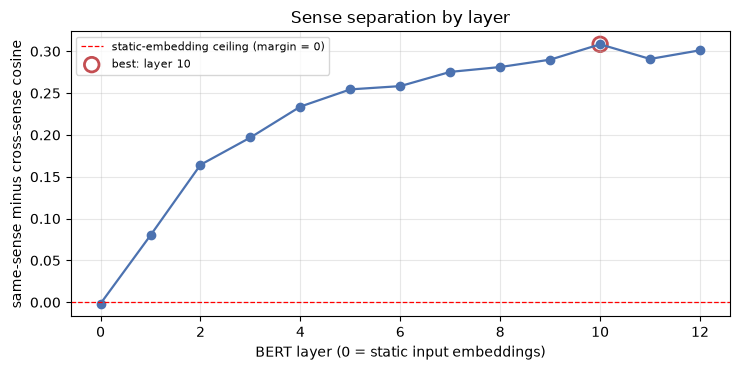

Layer 0 sits exactly on the red line: it is a lookup table, so all four occurrences of a
word are identical and the margin is 0 by construction -- the same limit every static model
faces. The rise through the middle layers is context being mixed in.


In [8]:
plt.figure(figsize=(7.5, 3.8))
plt.plot(range(len(layer_margins)), layer_margins, "o-", color="#4C72B0", lw=1.6)
plt.axhline(0, color="red", ls="--", lw=.9, label="static-embedding ceiling (margin = 0)")
plt.scatter([best_layer], [layer_margins[best_layer]], s=110, facecolors="none",
            edgecolors="#C44E52", lw=2, label=f"best: layer {best_layer}")
plt.xlabel("BERT layer (0 = static input embeddings)")
plt.ylabel("same-sense minus cross-sense cosine")
plt.title("Sense separation by layer")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("Layer 0 sits exactly on the red line: it is a lookup table, so all four occurrences of a")
print("word are identical and the margin is 0 by construction -- the same limit every static model")
print("faces. The rise through the middle layers is context being mixed in.")

In [9]:
# Static baselines on the same task.
rows = [("BERT layer 0 (static input)", *wsd_scores(Wctx[:, 0, :])),
        (f"BERT layer {best_layer} (best)", *wsd_scores(Wctx[:, best_layer, :])),
        (f"BERT layer {Wctx.shape[1] - 1} (top)", *wsd_scores(Wctx[:, -1, :]))]

for name, path in STATIC_AVAILABLE.items():
    vecs, dim = load_vectors(path, keep=set(words))
    missing = [w for w in dict.fromkeys(words) if w not in vecs]
    if missing:
        print(f"{name}: no vector for {missing} -- skipped")
        continue
    S = np.stack([vecs[w] for w in words])      # identical rows for identical words, by definition
    rows.append((f"{name} (dim {dim})", *wsd_scores(S)))

print(f"\n{'model':<34} {'same':>7} {'cross':>7} {'margin':>8}")
print("-" * 60)
for name, s, c, m in rows:
    print(f"{name:<34} {s:>7.3f} {c:>7.3f} {m:>+8.3f}")
print("\nEvery static row has margin exactly 0.000: one vector per type means same-sense and")
print("cross-sense similarity are the same number. No amount of extra training data changes this.")


model                                 same   cross   margin
------------------------------------------------------------
BERT layer 0 (static input)          0.961   0.962   -0.001
BERT layer 10 (best)                 0.795   0.486   +0.308
BERT layer 12 (top)                  0.773   0.472   +0.301
GloVe 6B.100d (dim 100)              1.000   1.000   +0.000

Every static row has margin exactly 0.000: one vector per type means same-sense and
cross-sense similarity are the same number. No amount of extra training data changes this.


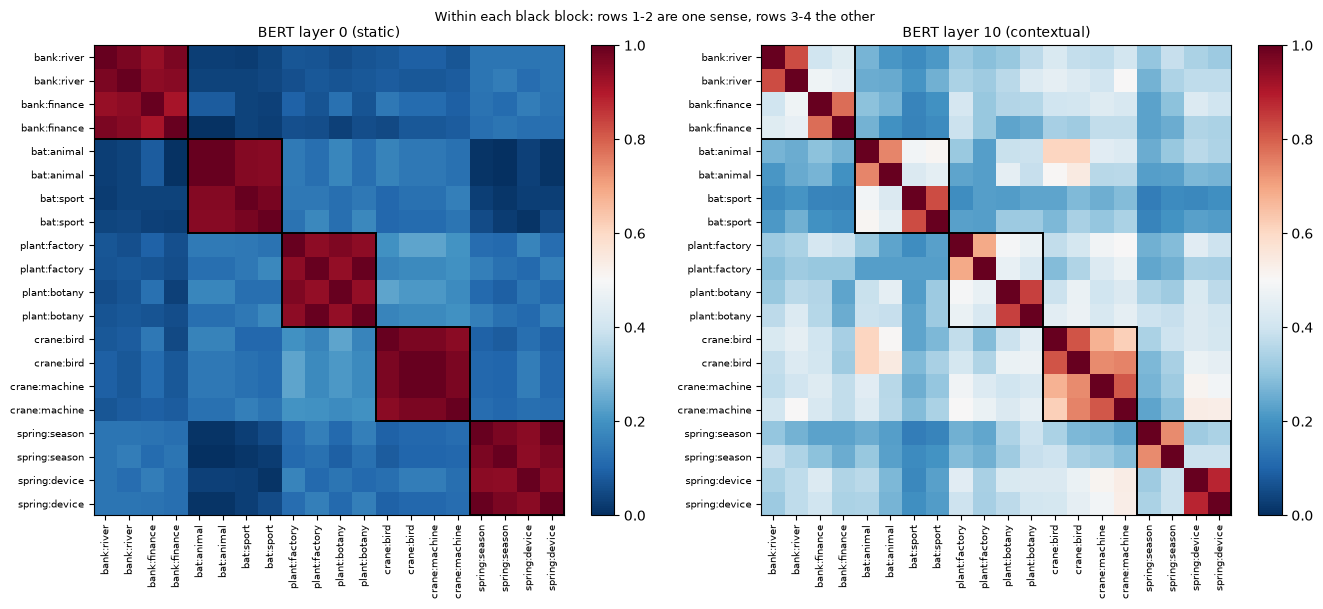

In [10]:
# Visual: the full 20x20 similarity matrix, static vs contextual.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6))
labels = [f"{w}:{s}" for w, s in zip(words, senses)]

for ax, (title, V) in zip(axes, [("BERT layer 0 (static)", Wctx[:, 0, :]),
                                 (f"BERT layer {best_layer} (contextual)", Wctx[:, best_layer, :])]):
    Vn = normalise_rows(V)
    im = ax.imshow(Vn @ Vn.T, cmap="RdBu_r", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)), labels=labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels)), labels=labels, fontsize=7)
    ax.set_title(title, fontsize=10)
    # mark the 4x4 blocks belonging to each word
    for k in range(0, len(labels), 4):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 4, 4, fill=False, ec="black", lw=1.4))
    plt.colorbar(im, ax=ax, fraction=.046)

plt.suptitle("Within each black block: rows 1-2 are one sense, rows 3-4 the other", fontsize=9)
plt.tight_layout(); plt.show()

Inside each black block, the contextual panel should show a **2×2 checkerboard** — bright on the
same-sense diagonal sub-blocks, darker off them. The static panel shows a uniform bright block: all
four occurrences are the same vector.

In [11]:
# Nearest-neighbour sanity check: for each occurrence, which other occurrence is closest?
V = normalise_rows(Wctx[:, best_layer, :])
correct = 0; total = 0
print(f"nearest same-word neighbour at layer {best_layer}:\n")
for i in range(len(WSD)):
    cands = [(float(V[i] @ V[j]), j) for j in range(len(WSD)) if j != i and words[j] == words[i]]
    sim, j = max(cands)
    ok = senses[j] == senses[i]
    correct += ok; total += 1
    print(f"  [{senses[i]:<8}] {sentences[i][:46]:<48} -> [{senses[j]:<8}] {'OK' if ok else 'WRONG'} ({sim:.3f})")

print(f"\nsame-sense retrieval accuracy: {correct}/{total} = {correct / total:.1%}")
print("Static baseline on this metric is chance (1/3 = 33.3%): with identical vectors the")
print("'nearest' neighbour is an arbitrary tie among the three other occurrences.")

nearest same-word neighbour at layer 10:

  [river   ] We had a picnic on the grassy bank of the rive   -> [river   ] OK (0.825)
  [river   ] The fisherman stood on the muddy bank watching   -> [river   ] OK (0.825)
  [finance ] The bank approved her mortgage application las   -> [finance ] OK (0.779)
  [finance ] He deposited his paycheck at the bank downtown   -> [finance ] OK (0.779)
  [animal  ] A bat flew out of the dark cave at dusk .        -> [animal  ] OK (0.746)
  [animal  ] The bat hunts insects using echolocation at ni   -> [animal  ] OK (0.746)
  [sport   ] He swung the bat and hit a home run .            -> [sport   ] OK (0.824)
  [sport   ] The player gripped his bat tightly before the    -> [sport   ] OK (0.824)
  [factory ] The chemical plant on the edge of town employs   -> [factory ] OK (0.688)
  [factory ] Production at the assembly plant halted for ma   -> [factory ] OK (0.688)
  [botany  ] This plant needs sunlight and water every day    -> [botany  ] OK (0.840)
 

<a id="4"></a>
## §4 — Sentence similarity

Second probe, at sentence level. Twelve sentence pairs in three groups:

* **paraphrase** — different words, same meaning. Both model families should score these high.
* **same topic, different meaning** — heavy lexical overlap, opposite or unrelated content. This is
  where mean-pooled static embeddings fail hardest: overlap alone drives their score up.
* **unrelated** — the control.

A useful sentence representation ranks paraphrase above same-topic above unrelated. Lexical overlap
alone ranks same-topic highest of all.

In [12]:
PAIRS = [
    # --- paraphrases: low lexical overlap, same meaning ---
    ("paraphrase", "The film was absolutely wonderful .", "I really enjoyed the movie ."),
    ("paraphrase", "She purchased a new automobile .", "She bought a new car ."),
    ("paraphrase", "The meeting was postponed .", "They rescheduled the meeting for later ."),
    ("paraphrase", "He is very good at mathematics .", "He excels in maths ."),

    # --- same topic, different (often opposite) meaning: high lexical overlap ---
    ("same topic", "The dog chased the cat .", "The cat chased the dog ."),
    ("same topic", "I like this movie a lot .", "I do not like this movie at all ."),
    ("same topic", "The stock market rose sharply today .", "The stock market fell sharply today ."),
    ("same topic", "She passed the difficult exam .", "She failed the difficult exam ."),

    # --- unrelated ---
    ("unrelated", "The chef prepared a delicious meal .", "Quantum computers use superposition ."),
    ("unrelated", "He plays the violin every evening .", "The tax deadline is in April ."),
    ("unrelated", "Snow covered the mountain peak .", "The database query timed out ."),
    ("unrelated", "Bees pollinate the flowering trees .", "He renewed his driving licence ."),
]

groups = [g for g, _, _ in PAIRS]
sent_a = [a for _, a, _ in PAIRS]
sent_b = [b for _, _, b in PAIRS]

def lexical_overlap(a, b):
    "Jaccard overlap of the token sets -- the signal a bag of words has access to."
    A = set(a.lower().replace(".", "").split()); B = set(b.lower().replace(".", "").split())
    return len(A & B) / max(len(A | B), 1)

print(f"{'group':<11} {'overlap':>8}  sentence pair")
for g, a, b in PAIRS:
    print(f"{g:<11} {lexical_overlap(a, b):>8.2f}  {a[:38]:<40} || {b[:38]}")

group        overlap  sentence pair
paraphrase      0.11  The film was absolutely wonderful .      || I really enjoyed the movie .
paraphrase      0.43  She purchased a new automobile .         || She bought a new car .
paraphrase      0.25  The meeting was postponed .              || They rescheduled the meeting for later
paraphrase      0.11  He is very good at mathematics .         || He excels in maths .
same topic      1.00  The dog chased the cat .                 || The cat chased the dog .
same topic      0.40  I like this movie a lot .                || I do not like this movie at all .
same topic      0.71  The stock market rose sharply today .    || The stock market fell sharply today .
same topic      0.67  She passed the difficult exam .          || She failed the difficult exam .
unrelated       0.00  The chef prepared a delicious meal .     || Quantum computers use superposition .
unrelated       0.09  He plays the violin every evening .      || The tax deadline is in Ap

In [13]:
ctx_a = contextual_vectors(sent_a)
ctx_b = contextual_vectors(sent_b)

def pair_cosines(A, B):
    An, Bn = normalise_rows(A), normalise_rows(B)
    return np.einsum("ij,ij->i", An, Bn)

# Contextual: mean-pooled tokens, at a middle layer and at the top layer.
MID = 6
scores = {
    f"BERT layer 0 mean (static)":      pair_cosines(ctx_a["sentence"][:, 0], ctx_b["sentence"][:, 0]),
    f"BERT layer {MID} mean":           pair_cosines(ctx_a["sentence"][:, MID], ctx_b["sentence"][:, MID]),
    "BERT top layer mean":              pair_cosines(ctx_a["sentence"][:, -1], ctx_b["sentence"][:, -1]),
    "BERT [CLS], top layer":            pair_cosines(ctx_a["cls"][:, -1], ctx_b["cls"][:, -1]),
    "lexical overlap (Jaccard)":        np.array([lexical_overlap(a, b) for a, b in zip(sent_a, sent_b)]),
}

# Static: mean of word vectors per sentence.
all_words = {w for s in sent_a + sent_b for w in s.lower().replace(".", "").split()}
for name, path in STATIC_AVAILABLE.items():
    vecs, dim = load_vectors(path, keep=all_words)
    def sent_vec(s):
        hit = [vecs[w] for w in s.lower().replace(".", "").split() if w in vecs]
        return np.mean(hit, axis=0) if hit else np.zeros(dim, dtype=np.float32)
    A = np.stack([sent_vec(s) for s in sent_a]); B = np.stack([sent_vec(s) for s in sent_b])
    scores[f"{name} mean"] = pair_cosines(A, B)

print(f"{'model':<30} " + "  ".join(f"{g[:9]:>9}" for g in ["paraphrase", "same topic", "unrelated"])
      + f" {'para-topic':>11}")
print("-" * 78)
summary_rows = []
for name, sc in scores.items():
    per_group = {g: float(np.mean([s for s, gg in zip(sc, groups) if gg == g]))
                 for g in ["paraphrase", "same topic", "unrelated"]}
    gap = per_group["paraphrase"] - per_group["same topic"]
    summary_rows.append((name, per_group, gap))
    print(f"{name:<30} " + "  ".join(f"{per_group[g]:>9.3f}" for g in
          ["paraphrase", "same topic", "unrelated"]) + f" {gap:>+11.3f}")

model                          paraphras  same topi  unrelated  para-topic
------------------------------------------------------------------------------
BERT layer 0 mean (static)         0.725      0.912      0.432      -0.187
BERT layer 6 mean                  0.861      0.953      0.685      -0.092
BERT top layer mean                0.834      0.941      0.542      -0.107
BERT [CLS], top layer              0.937      0.980      0.801      -0.043
lexical overlap (Jaccard)          0.225      0.695      0.051      -0.470
GloVe 6B.100d mean                 0.927      0.985      0.499      -0.059


The rightmost column is the discriminating measure: **paraphrase similarity minus same-topic
similarity.** A model that understands meaning scores it positive. A model driven by lexical overlap
scores it *negative*, because the same-topic pairs share more words than the paraphrases do — look at
the Jaccard row to confirm that the overlap really does run the wrong way here.

This is by design: the same-topic pairs are near-minimal edits that reverse meaning (`rose`/`fell`,
`passed`/`failed`, `like`/`do not like`), so any order-blind, negation-blind representation must rank
them as highly similar.

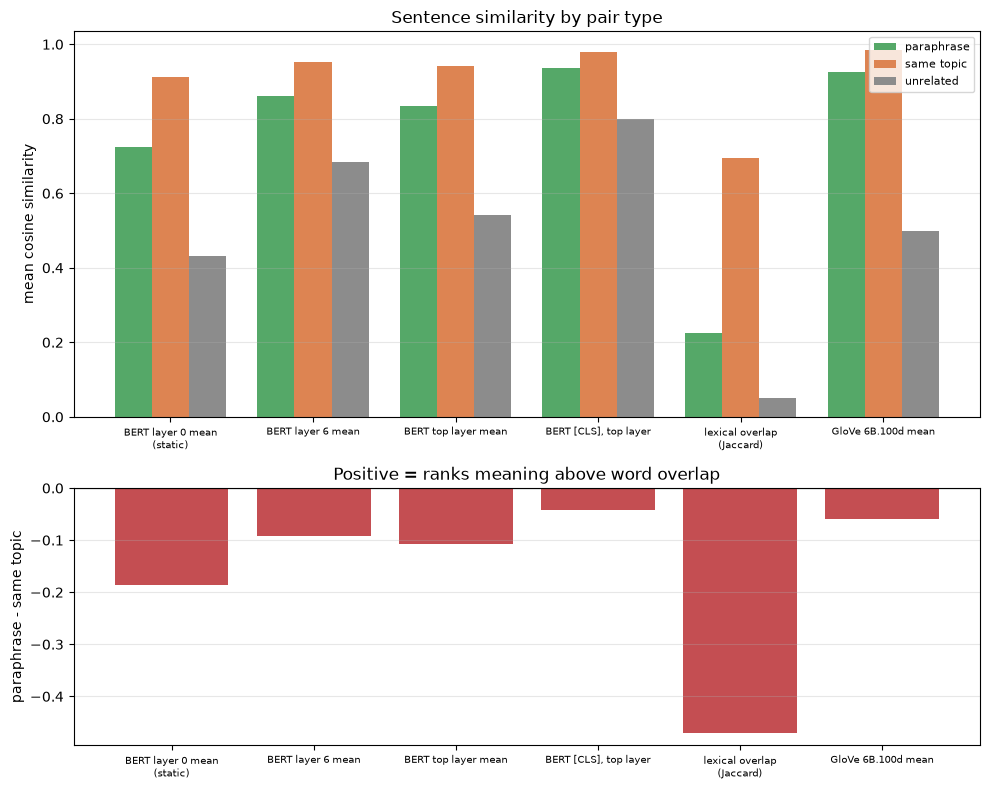

In [14]:
names = [n for n, _, _ in summary_rows]
x = np.arange(len(names))
w = 0.26
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 2]})

for k, (g, col) in enumerate(zip(["paraphrase", "same topic", "unrelated"],
                                 ["#55A868", "#DD8452", "#8C8C8C"])):
    axes[0].bar(x + (k - 1) * w, [r[1][g] for r in summary_rows], w, label=g, color=col)
axes[0].set_xticks(x, [n.replace(" (", "\n(") for n in names], fontsize=7.5)
axes[0].set_ylabel("mean cosine similarity"); axes[0].legend(fontsize=8)
axes[0].set_title("Sentence similarity by pair type"); axes[0].grid(alpha=.3, axis="y")

gaps = [r[2] for r in summary_rows]
axes[1].bar(x, gaps, color=["#4C72B0" if g > 0 else "#C44E52" for g in gaps])
axes[1].axhline(0, color="black", lw=.8)
axes[1].set_xticks(x, [n.replace(" (", "\n(") for n in names], fontsize=7.5)
axes[1].set_ylabel("paraphrase - same topic")
axes[1].set_title("Positive = ranks meaning above word overlap")
axes[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

In [15]:
# The single most diagnostic pair, model by model.
i = next(k for k, (g, a, b) in enumerate(PAIRS) if "not like" in b)
print(f"pair: {sent_a[i]!r}\n      {sent_b[i]!r}")
print(f"lexical overlap: {lexical_overlap(sent_a[i], sent_b[i]):.2f}  (opposite meaning)\n")
for name, sc in scores.items():
    print(f"  {name:<30} {sc[i]:.3f}")
print("\nEvery mean-pooled model -- static or contextual -- scores this pair high: 'not' is one token")
print("among ten, and averaging cannot let it flip the rest. Negation needs either an architecture")
print("that reads order (the [CLS] vector of a fine-tuned model) or explicit n-gram features.")

pair: 'I like this movie a lot .'
      'I do not like this movie at all .'
lexical overlap: 0.40  (opposite meaning)

  BERT layer 0 mean (static)     0.837
  BERT layer 6 mean              0.863
  BERT top layer mean            0.843
  BERT [CLS], top layer          0.963
  lexical overlap (Jaccard)      0.400
  GloVe 6B.100d mean             0.969

Every mean-pooled model -- static or contextual -- scores this pair high: 'not' is one token
among ten, and averaging cannot let it flip the rest. Negation needs either an architecture
that reads order (the [CLS] vector of a fine-tuned model) or explicit n-gram features.


<a id="5"></a>
## §5 — Interpretability: what you can and cannot inspect

"Interpretable" means different things for the two families, and the difference is structural rather
than a matter of tooling.

**Static embeddings** are a matrix you can read. Row $i$ *is* word $i$'s meaning; you can list
neighbours, do vector arithmetic, and audit the table for bias by inspecting fixed rows. The
representation is a finite object with 400 000 entries.

**Contextual embeddings** have no such object. There is no row for `bank` — only a function that
maps (token, context) to a vector, and that function is 110 M parameters spread over 12 layers. What
you can inspect instead:

* how a word's vector *moves* with context (§3 — this is exactly what a static table cannot express);
* attention patterns, though attention weights are a weak explanation of the computation;
* per-layer behaviour: which layer encodes what (probing).

The measurements below make the trade-off concrete.

In [16]:
# 1. Anisotropy: how similar are two RANDOM words' vectors in each space?
#    Static spaces are roughly isotropic; BERT's upper layers are famously not, which inflates
#    every cosine and is why raw BERT cosines need care when read as similarity.
random.seed(SEED)
FILLER = ["The cat sat quietly on the warm mat .",
          "Engineers repaired the bridge over the wide river .",
          "She read an interesting book about ancient history .",
          "Rain fell steadily throughout the cold autumn night .",
          "The committee approved the budget after long debate .",
          "Children played football in the empty school yard .",
          "He brewed strong coffee before the morning meeting .",
          "Scientists published their findings in a major journal ."]

filler = contextual_vectors(FILLER)
print(f"{'representation':<32} {'mean cos of random pairs':>26}")
print("-" * 60)
for l in [0, MID, 12]:
    Vf = normalise_rows(filler["sentence"][:, l])
    S = Vf @ Vf.T
    off = S[~np.eye(len(S), dtype=bool)]
    print(f"BERT layer {l:<21} {off.mean():>26.3f}")

for name, path in STATIC_AVAILABLE.items():
    vecs, dim = load_vectors(path, keep=all_words | {w for s in FILLER for w in s.lower().replace('.','').split()})
    sample = random.sample(list(vecs.values()), min(200, len(vecs)))
    Vs = normalise_rows(np.stack(sample))
    S = Vs @ Vs.T
    off = S[~np.eye(len(S), dtype=bool)]
    print(f"{name:<32} {off.mean():>26.3f}")

print("\nHigh values mean the space is anisotropic -- vectors crowded into a narrow cone. A cosine")
print("of 0.6 in a space whose random baseline is 0.55 conveys much less than the same 0.6 where")
print("the baseline is 0.05. Any comparison across these rows must account for this offset.")

representation                     mean cos of random pairs
------------------------------------------------------------
BERT layer 0                                          0.529
BERT layer 6                                          0.738
BERT layer 12                                         0.568


GloVe 6B.100d                                         0.309

High values mean the space is anisotropic -- vectors crowded into a narrow cone. A cosine
of 0.6 in a space whose random baseline is 0.55 conveys much less than the same 0.6 where
the baseline is 0.05. Any comparison across these rows must account for this offset.


In [17]:
# 2. Static interpretability, demonstrated: neighbours and arithmetic in the GloVe table.
if "GloVe 6B.100d" in STATIC_AVAILABLE:
    NEIGH_VOCAB = 50_000        # top rows of the file are the most frequent words
    words_seen, mat = [], []
    with open(GLOVE_TXT, "r", encoding="utf-8") as fh:
        for k, line in enumerate(fh):
            if k >= NEIGH_VOCAB:
                break
            parts = line.rstrip().split(" ")
            words_seen.append(parts[0]); mat.append(np.asarray(parts[1:], dtype=np.float32))
    G = normalise_rows(np.stack(mat))
    gidx = {w: i for i, w in enumerate(words_seen)}

    def nearest(word, k=6):
        if word not in gidx: return []
        sims = G @ G[gidx[word]]; sims[gidx[word]] = -np.inf
        top = np.argsort(-sims)[:k]
        return [(words_seen[i], float(sims[i])) for i in top]

    print("GloVe nearest neighbours -- a direct read of the table:")
    for w in ["bank", "bat", "plant", "spring"]:
        print(f"  {w:<8} " + ", ".join(f"{n} ({s:.2f})" for n, s in nearest(w)))

    print("\nNote how each list MIXES the senses -- 'plant' pulls both factories and vegetation.")
    print("The single vector is a frequency-weighted average of every sense, which is precisely")
    print("the failure §3 measured.\n")

    def analogy(a, b, c, k=3):
        if any(w not in gidx for w in (a, b, c)): return []
        q = G[gidx[b]] - G[gidx[a]] + G[gidx[c]]
        q /= np.linalg.norm(q)
        sims = G @ q
        for w in (a, b, c): sims[gidx[w]] = -np.inf
        return [(words_seen[i], float(sims[i])) for i in np.argsort(-sims)[:k]]

    print("Vector arithmetic -- available because the space is a fixed, inspectable table:")
    for a, b, c in [("man", "woman", "king"), ("paris", "france", "tokyo"),
                    ("good", "better", "bad"), ("walk", "walked", "run")]:
        print(f"  {a} : {b} :: {c} : " + ", ".join(f"{w} ({s:.2f})" for w, s in analogy(a, b, c)))
    print("\nBERT has no equivalent operation: there is no row for 'king' to subtract from.")

GloVe nearest neighbours -- a direct read of the table:
  bank     banks (0.81), banking (0.75), credit (0.70), investment (0.69), financial (0.68), securities (0.67)
  bat      bats (0.71), balls (0.68), pitch (0.66), batting (0.64), wicket (0.64), ball (0.64)
  plant    plants (0.89), factory (0.71), farm (0.66), facility (0.65), production (0.63), produce (0.62)
  spring   summer (0.86), autumn (0.82), winter (0.80), beginning (0.74), fall (0.72), start (0.70)

Note how each list MIXES the senses -- 'plant' pulls both factories and vegetation.
The single vector is a frequency-weighted average of every sense, which is precisely
the failure §3 measured.

Vector arithmetic -- available because the space is a fixed, inspectable table:
  man : woman :: king : queen (0.77), monarch (0.68), throne (0.68)
  paris : france :: tokyo : japan (0.89), korea (0.72), japanese (0.69)
  good : better :: bad : worse (0.84), too (0.75), even (0.73)
  walk : walked :: run : went (0.71), drove (0.71), r

In [18]:
# 3. Contextual interpretability, demonstrated: watch one word's vector move.
SHIFT = [
    ("The bank of the river was muddy .",              "bank"),
    ("The bank raised its interest rates .",           "bank"),
    ("He robbed a bank downtown .",                    "bank"),
    ("We banked the canoe on the sandy bank .",         "bank"),
]
shift_ctx = contextual_vectors([s for s, _ in SHIFT], target_words=[w for _, w in SHIFT])
Vs = normalise_rows(shift_ctx["word"][:, best_layer, :])

print(f"pairwise cosine between the four 'bank' vectors, BERT layer {best_layer}:\n")
print("      " + "".join(f"{i:>7}" for i in range(len(SHIFT))))
for i in range(len(SHIFT)):
    print(f"  {i}   " + "".join(f"{float(Vs[i] @ Vs[j]):>7.3f}" for j in range(len(SHIFT))))
for i, (s, _) in enumerate(SHIFT):
    print(f"  {i}: {s}")
print("\nSentences 0 and 3 (river sense) group; 1 and 2 (finance sense) group. One word type,")
print("four vectors, and the grouping recovers the senses -- with no sense inventory supplied.")

pairwise cosine between the four 'bank' vectors, BERT layer 10:

            0      1      2      3
  0     1.000  0.523  0.497  0.727
  1     0.523  1.000  0.702  0.424
  2     0.497  0.702  1.000  0.424
  3     0.727  0.424  0.424  1.000
  0: The bank of the river was muddy .
  1: The bank raised its interest rates .
  2: He robbed a bank downtown .
  3: We banked the canoe on the sandy bank .

Sentences 0 and 3 (river sense) group; 1 and 2 (finance sense) group. One word type,
four vectors, and the grouping recovers the senses -- with no sense inventory supplied.


<a id="6"></a>
## §6 — Results summary

In [19]:
wsd_static = 0.0
wsd_bert_best = layer_margins[best_layer]
para_gap = {n: g for n, _, g in summary_rows}

print("WORD SENSE DISAMBIGUATION (same-sense minus cross-sense cosine; higher is better)")
print(f"  static embeddings, any dimension, any corpus : {wsd_static:+.3f}   (structurally fixed at 0)")
print(f"  BERT layer 0 (its own static table)          : {wsd_scores(Wctx[:, 0, :])[2]:+.3f}")
print(f"  BERT layer {best_layer} (best)                          : {wsd_bert_best:+.3f}")
print(f"  same-sense retrieval accuracy, layer {best_layer}       : {correct / total:.1%} (static: 33.3% chance)")

print("\nSENTENCE SIMILARITY (paraphrase minus same-topic cosine; positive means meaning beats overlap)")
for n, g in para_gap.items():
    print(f"  {n:<44} {g:+.3f}")

print("\nCOST")
print(f"  GloVe 100d       : {GLOVE_TXT.stat().st_size / 1e6:.0f} MB table, one array lookup per word")
print(f"  BERT base        : {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters, "
      f"a 12-layer forward pass per sentence")

payload = {
    "wsd": {"static_margin": wsd_static,
            "bert_layer0_margin": round(wsd_scores(Wctx[:, 0, :])[2], 4),
            "bert_best_layer": best_layer,
            "bert_best_margin": round(wsd_bert_best, 4),
            "bert_retrieval_accuracy": round(correct / total, 4),
            "layer_margins": [round(m, 4) for m in layer_margins]},
    "sentence_similarity": {k: round(v, 4) for k, v in para_gap.items()},
}
(ARTIFACTS / "assignment5_results.json").write_text(json.dumps(payload, indent=2))
print(f"\nsaved {ARTIFACTS / 'assignment5_results.json'}")

WORD SENSE DISAMBIGUATION (same-sense minus cross-sense cosine; higher is better)
  static embeddings, any dimension, any corpus : +0.000   (structurally fixed at 0)
  BERT layer 0 (its own static table)          : -0.001
  BERT layer 10 (best)                          : +0.308
  same-sense retrieval accuracy, layer 10       : 100.0% (static: 33.3% chance)

SENTENCE SIMILARITY (paraphrase minus same-topic cosine; positive means meaning beats overlap)
  BERT layer 0 mean (static)                   -0.187
  BERT layer 6 mean                            -0.092
  BERT top layer mean                          -0.107
  BERT [CLS], top layer                        -0.043
  lexical overlap (Jaccard)                    -0.470
  GloVe 6B.100d mean                           -0.059

COST
  GloVe 100d       : 347 MB table, one array lookup per word
  BERT base        : 109M parameters, a 12-layer forward pass per sentence

saved artifacts/assignment5_results.json


<a id="7"></a>
## §7 — Discussion

### Where contextual embeddings win outright

**Polysemy.** Not "better on average" — *categorically* different. A static table assigns `bank` one
vector, so the same-sense/cross-sense margin is exactly zero no matter how large the training corpus.
BERT's middle layers separate the senses without ever being given a sense inventory. §3 puts a number
on a gap that no amount of static-model scaling can close.

**Out-of-vocabulary words.** WordPiece decomposition means BERT always produces *something*.
`antidisestablishmentarianism` gets a composed representation; GloVe returns nothing at all.

**Order and syntax.** BERT's self-attention reads position. Static vectors do not have the concept.
Note, though, that §4's negation pair fools mean-pooled BERT too — the capability is in the model, but
mean-pooling throws it away. Sentence-level tasks need either the `[CLS]` vector from a
sentence-trained model (SBERT) or fine-tuning.

### Where static embeddings still earn their place

**Cost.** One table lookup versus a 12-layer forward pass — three to four orders of magnitude in
compute per token. For a keyword-similarity service over millions of queries, that is the decision.

**Interpretability.** The table is finite and directly auditable: read row $i$, list neighbours, do
arithmetic, audit for bias by inspecting fixed rows. BERT offers no row to inspect — only behaviour
to probe, and probing results depend on the probe.

**Small labelled datasets.** Assignment 4 showed frozen 100-dimensional GloVe means competing with
TF-IDF on 1 400 examples. Fine-tuning BERT on 1 400 examples is possible but easily unstable, and the
frozen-BERT-features alternative gives up much of what makes BERT worth the cost.

**Anisotropy.** §5's random-pair baseline is the practical catch: raw BERT cosines are inflated and
compressed into a narrow cone, so a cosine of 0.8 may mean very little. Static spaces are closer to
isotropic, making their cosines more directly readable. Fixes exist — centering, whitening,
contrastive training as in SBERT — but they are extra machinery.

### Choosing between them

| Situation | Choice |
|---|---|
| Word senses matter (WSD, entity linking) | contextual — static cannot do this at all |
| Millions of lookups, latency-bound | static |
| Need to audit or explain the representation | static |
| Plenty of labelled data, accuracy is the target | contextual, fine-tuned |
| Sentence similarity at scale | contextual, but sentence-trained (SBERT), not mean-pooled BERT |
| Small labelled dataset, tight compute | static, frozen |

### Limitations of this analysis

1. **20 sentences, 5 words.** Enough to demonstrate the mechanism, nowhere near enough for a
   published number. Real WSD evaluation uses SemEval / SemCor with thousands of annotated instances.
2. **Hand-written sentence pairs.** Constructed to expose the failure modes discussed. STS-B would
   give comparable numbers on natural data.
3. **No fine-tuning.** BERT is used frozen throughout, which understates it — most of its practical
   advantage comes from fine-tuning on the target task.
4. **Mean-pooling for sentences.** The weakest reasonable way to use BERT at sentence level, chosen
   so the comparison against mean-pooled static vectors holds the pooling constant. SBERT would be
   the right tool for a sentence-similarity system.

**References**

1. Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language
   Understanding.* NAACL.
2. Peters et al. (2018). *Deep Contextualized Word Representations.* NAACL. — ELMo
3. Reimers & Gurevych (2019). *Sentence-BERT.* EMNLP. — why mean-pooled BERT underperforms for
   sentence similarity, and what to do instead
4. Ethayarajh (2019). *How Contextual are Contextualized Word Representations?* EMNLP. — the
   anisotropy measured in §5
5. Tenney, Das & Pavlick (2019). *BERT Rediscovers the Classical NLP Pipeline.* ACL. — which layer
   encodes what
6. Wiedemann et al. (2019). *Does BERT Make Any Sense?* KONVENS. — BERT embeddings for WSD